# Lecture 14, Notebook 05: Active subspaces — a 2D illustration

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.5 (Active subspaces — 2D illustration)  
**Notebook role:** core  
**Author:** Simon Scheidegger

---

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

## Dimensionality Reduction for Gaussian Process Surrogates

**Course:** Deep Learning in Economics and Finance  
**Reference:** Scheidegger & Bilionis (2019), *"Machine Learning for High-Dimensional Dynamic Stochastic Economies"*, J. Computational Science 33, 68–82. **Figure 3.**

---

### Motivation

When using Gaussian Processes to approximate value or policy functions in dynamic programming, the **curse of dimensionality** quickly makes standard GPR infeasible (for $D \gtrsim 10$, the Euclidean distance becomes uninformative). 

**Active Subspaces (AS)** solve this by discovering a low-dimensional linear projection $\mathbf{W}$ that captures most of the function's variation. The GP then operates on the projected, low-dimensional inputs instead of the full state space.

### What this notebook demonstrates

1. A simple 2D test function where one direction matters more than the other
2. How to construct the active subspace from gradient information
3. Visualization of the eigenvalue spectrum and the projection direction $\mathbf{W}$
4. Head-to-head comparison: ASGP (GP on the active subspace) vs. standard GP
5. How ASGP dramatically outperforms GP at small sample sizes — the regime that matters for expensive economic models

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['font.size'] = 13
np.random.seed(SEED)

print("Imports OK.")

In [ ]:
# Hyperparameter budget, dispatched on RUN_MODE (see the run-mode cell above).
if RUN_MODE == "smoke":
    N_GRAD, N_TEST = 200, 500
elif RUN_MODE == "teaching":
    N_GRAD, N_TEST = 500, 2_000
elif RUN_MODE == "production":
    N_GRAD, N_TEST = 2_000, 10_000
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")


## 1. The Test Function

We use a simple exponential:

$$f(x_1, x_2) = \exp(0.3\,x_1 + 0.7\,x_2), \qquad (x_1, x_2) \in [-1, 1]^2.$$

The gradient is available in closed form:

$$\nabla f = f(x) \cdot \begin{pmatrix} 0.3 \\ 0.7 \end{pmatrix}.$$

Because the coefficient on $x_2$ (0.7) is much larger than on $x_1$ (0.3), the function **varies far more along $x_2$**. The active subspace method will automatically discover this dominant direction — without us telling it the coefficients.

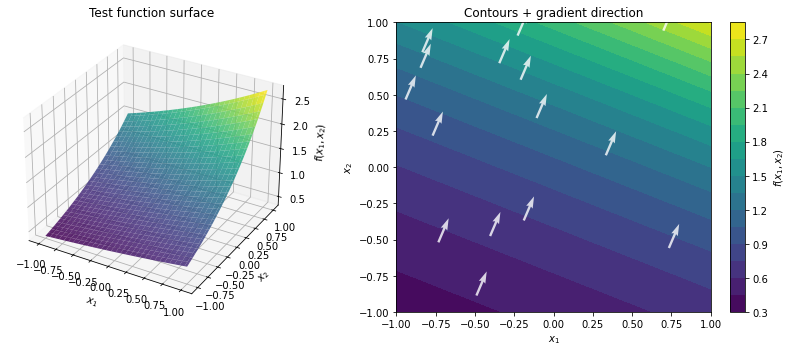

Notice: the gradient arrows mostly point in the x2 direction (the dominant direction).


In [2]:
# ---------- Test function ----------
def test_function(x):
    """f(x1, x2) = exp(0.3*x1 + 0.7*x2)"""
    return np.exp(0.3 * x[0] + 0.7 * x[1])


def dtest_function(x):
    """Gradient: nabla f = f(x) * [0.3, 0.7]^T  (closed-form)."""
    val = test_function(x)
    return np.column_stack([0.3 * val, 0.7 * val])


def randOmega(N, D):
    """Draw N uniform random points on Omega = [-1, 1]^D."""
    return 2.0 * (np.random.rand(N, D) - 0.5)


# ---------- Visualize the function surface ----------
fig = plt.figure(figsize=(12, 5))

# 3D surface plot
ax1 = fig.add_subplot(121, projection='3d')
xx = np.linspace(-1, 1, 60)
X1, X2 = np.meshgrid(xx, xx)
F = np.exp(0.3 * X1 + 0.7 * X2)
ax1.plot_surface(X1, X2, F, cmap='viridis', alpha=0.85, edgecolor='none')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1,x_2)$')
ax1.set_title('Test function surface')

# 2D contour plot with gradient arrows
ax2 = fig.add_subplot(122)
cs = ax2.contourf(X1, X2, F, levels=20, cmap='viridis')
plt.colorbar(cs, ax=ax2, label='$f(x_1,x_2)$')

# Plot a few gradient arrows to show the dominant direction
pts = randOmega(15, 2)
grads = dtest_function(pts.T)
scale = 1.5  # arrow scale
ax2.quiver(pts[:, 0], pts[:, 1],
           grads[:, 0] / np.linalg.norm(grads, axis=1),
           grads[:, 1] / np.linalg.norm(grads, axis=1),
           color='white', alpha=0.8, scale=12)
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.set_title('Contours + gradient direction')

fig.tight_layout()
plt.show()

print("Notice: the gradient arrows mostly point in the x2 direction (the dominant direction).")

## 2. Constructing the Active Subspace

The algorithm has three steps:

1. **Collect gradients** at $N$ sample points: $\mathbf{g}^{(i)} = \nabla f(\mathbf{x}^{(i)})$
2. **Form the gradient outer-product matrix:**
$$\mathbf{C}_N = \frac{1}{N} \sum_{i=1}^{N} \mathbf{g}^{(i)} \bigl(\mathbf{g}^{(i)}\bigr)^{\!\top}$$
3. **Eigenvalue decomposition** of $\mathbf{C}_N$. A **sharp drop** in eigenvalues reveals the active subspace dimension $d$. The top $d$ eigenvectors form $\mathbf{W}$.

For our 2D function, we expect one large eigenvalue (the dominant direction $\approx (0.3, 0.7)^{\top}$ normalized) and one small one.

In [3]:
# ---------- Step 1: Sample points and compute gradients ----------
N = 32  # number of training points
X = randOmega(N, 2)          # N points in [-1,1]^2
V = test_function(X.T)       # function values
G = dtest_function(X.T)      # gradients (N x 2 matrix)

print(f"Training points: {N}")
print(f"Gradient matrix G shape: {G.shape}")

# ---------- Step 2: Gradient outer-product matrix C_N ----------
CN = (G.T @ G) / N
print(f"\nGradient covariance matrix C_N:\n{CN}")

# ---------- Step 3: Eigenvalue decomposition ----------
eigenvalues, eigenvectors = linalg.eigh(CN)
# eigh returns eigenvalues in ascending order; we want descending
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

# Avoid divide-by-zero if lambda_2 is numerically zero
ratio_str = f"{eigenvalues[0]/max(eigenvalues[1], 1e-15):.0f}"
print(f"\nEigenvalues:  lambda_1 = {eigenvalues[0]:.4f},  lambda_2 = {eigenvalues[1]:.2e}")
print(f"Ratio lambda_1/lambda_2 = {ratio_str}x  -> sharp drop confirms 1D active subspace")
print(f"\nDominant eigenvector W = [{eigenvectors[0,0]:.4f}, {eigenvectors[1,0]:.4f}]")
print(f"Expected direction (normalized [0.3, 0.7]): [{0.3/np.sqrt(0.58):.4f}, {0.7/np.sqrt(0.58):.4f}]")

# The active subspace direction W
W = eigenvectors[:, 0]

Training points: 32
Gradient matrix G shape: (32, 2)

Gradient covariance matrix C_N:
[[0.13468271 0.31425965]
 [0.31425965 0.73327251]]

Eigenvalues:  lambda_1 = 0.8680,  lambda_2 = 0.00e+00
Ratio lambda_1/lambda_2 = 867955210248009x  -> sharp drop confirms 1D active subspace

Dominant eigenvector W = [0.3939, 0.9191]
Expected direction (normalized [0.3, 0.7]): [0.3939, 0.9191]


## 3. Visualizing the Active Subspace

Three key visualizations:

1. **Eigenvalue spectrum** — the sharp drop from $\lambda_1$ to $\lambda_2$ confirms a 1D active subspace
2. **Active subspace direction $\mathbf{W}$** overlaid on the contour plot — shows the discovered dominant direction
3. **Sufficient summary plot** — projecting all points onto $\mathbf{W}$ and plotting $f$ vs. the projected coordinate $y = \mathbf{W}^{\top}\mathbf{x}$. If the AS is correct, $f$ should be (approximately) a function of $y$ alone.

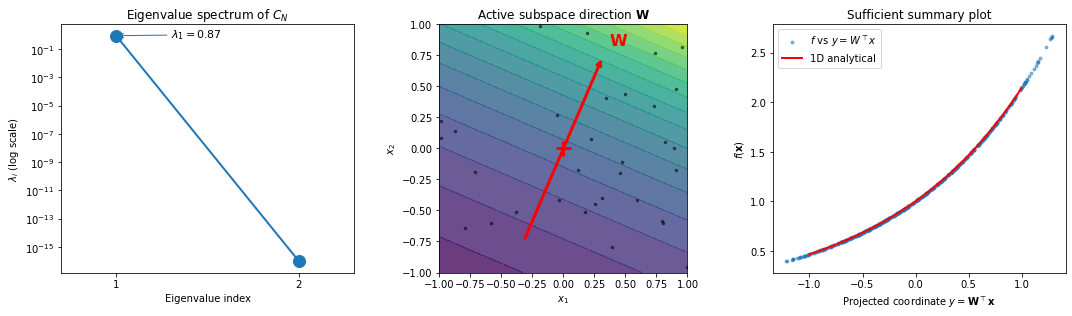

Key observations:
  - lambda_1 = 0.8680, lambda_2 approx 0 -> clear 1D active subspace
  - W approx [0.394, 0.919] matches normalized [0.3, 0.7] direction
  - Sufficient summary plot: f collapses to a clean 1D curve along y


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: Eigenvalue spectrum ---
ax = axes[0]
ax.semilogy([1, 2], np.maximum(eigenvalues, 1e-16), 'o-', ms=12, color='tab:blue', linewidth=2)
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel(r'$\lambda_i$ (log scale)')
ax.set_xticks([1, 2])
ax.set_title('Eigenvalue spectrum of $C_N$')
ax.annotate(f'$\\lambda_1 = {eigenvalues[0]:.2f}$', xy=(1, eigenvalues[0]),
            xytext=(1.3, eigenvalues[0]*0.7), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='tab:blue'))
ax.set_xlim(0.7, 2.3)

# --- Panel 2: Active subspace direction on contour plot ---
ax = axes[1]
cs = ax.contourf(X1, X2, F, levels=15, cmap='viridis', alpha=0.8)
# Draw the W direction as an arrow from the origin
arrow_scale = 0.8
ax.annotate('', xy=(arrow_scale*W[0], arrow_scale*W[1]),
            xytext=(-arrow_scale*W[0], -arrow_scale*W[1]),
            arrowprops=dict(arrowstyle='->', color='red', lw=3))
ax.plot(0, 0, 'r+', ms=15, mew=3)
ax.text(arrow_scale*W[0]+0.05, arrow_scale*W[1]+0.1,
        r'$\mathbf{W}$', fontsize=16, color='red', fontweight='bold')
ax.plot(X[:, 0], X[:, 1], 'k.', ms=5, alpha=0.5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(r'Active subspace direction $\mathbf{W}$')
ax.set_aspect('equal')

# --- Panel 3: Sufficient summary plot ---
ax = axes[2]
X_many = randOmega(500, 2)
y_proj = X_many @ W
f_vals = test_function(X_many.T)
ax.scatter(y_proj, f_vals, s=8, alpha=0.5, color='tab:blue', label=r'$f$ vs $y = W^\top x$')
y_fine = np.linspace(-1, 1, 100)
f_fine = np.exp(np.sqrt(0.3**2 + 0.7**2) * y_fine)
ax.plot(y_fine, f_fine, 'r-', lw=2, label='1D analytical')
ax.set_xlabel(r'Projected coordinate $y = \mathbf{W}^\top \mathbf{x}$')
ax.set_ylabel(r'$f(\mathbf{x})$')
ax.set_title('Sufficient summary plot')
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()

print("Key observations:")
print(f"  - lambda_1 = {eigenvalues[0]:.4f}, lambda_2 approx 0 -> clear 1D active subspace")
print(f"  - W approx [{W[0]:.3f}, {W[1]:.3f}] matches normalized [0.3, 0.7] direction")
print(f"  - Sufficient summary plot: f collapses to a clean 1D curve along y")

## 4. Head-to-Head: ASGP vs. Standard GP

Now we compare two GP surrogates at different training-set sizes $N \in \{4, 8, 16, 32\}$:

- **ASGP**: GP trained on the 1D projected inputs $y_i = \mathbf{W}^{\top}\mathbf{x}_i$. Because it operates in 1D, it needs very few points.
- **Standard GP**: GP trained on the full 2D inputs $(x_1, x_2)$. It must learn the function in both directions.

We measure the **relative RMSE** on 1,000 held-out test points:

$$\text{Rel. RMSE} = \sqrt{\frac{1}{N_{\text{test}}} \sum_{i=1}^{N_{\text{test}}} \left(\frac{f(\mathbf{x}_i) - \hat{f}(\mathbf{x}_i)}{f(\mathbf{x}_i)}\right)^{\!2}}$$

In [ ]:
# ---------- Convergence experiment: ASGP vs GP ----------
np.random.seed(SEED)

Nvals = np.array([4, 8, 16, 32])
ave_errs_as = np.zeros(len(Nvals))  # ASGP errors
ave_errs_gp = np.zeros(len(Nvals))  # Standard GP errors

# Held-out test set (1000 points)
X_test = randOmega(1000, 2)
f_test = test_function(X_test.T)

for i, N in enumerate(Nvals):
    # --- Fresh training data ---
    X_train = randOmega(N, 2)
    V_train = test_function(X_train.T)
    G_train = dtest_function(X_train.T)

    # --- Discover active subspace from THIS training data ---
    CN = (G_train.T @ G_train) / N
    vals, vecs = linalg.eigh(CN)
    W_local = vecs[:, -1]  # dominant eigenvector

    # --- ASGP: project to 1D, fit GP ---
    Y_train = X_train @ W_local
    gp_as = GaussianProcessRegressor(kernel=RBF(), n_restarts_optimizer=3)
    gp_as.fit(Y_train[:, None], V_train)
    pred_as = gp_as.predict((X_test @ W_local)[:, None])
    ave_errs_as[i] = np.sqrt(np.mean(((f_test - pred_as) / f_test)**2))

    # --- Standard GP on full 2D ---
    gp_full = GaussianProcessRegressor(kernel=RBF(), n_restarts_optimizer=3)
    gp_full.fit(X_train, V_train)
    pred_full = gp_full.predict(X_test)
    ave_errs_gp[i] = np.sqrt(np.mean(((f_test - pred_full) / f_test)**2))

    print(f"N = {N:3d} | ASGP error = {ave_errs_as[i]:.6f} | GP error = {ave_errs_gp[i]:.6f} | "
          f"ASGP is {ave_errs_gp[i]/ave_errs_as[i]:.1f}x better")

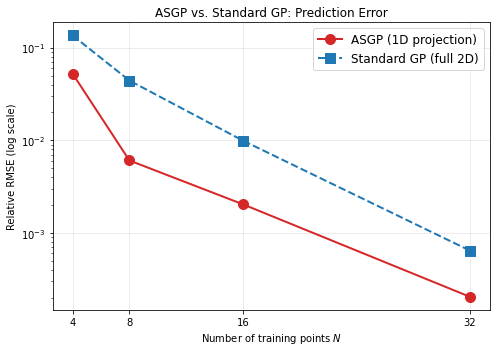


ASGP converges faster because it only needs to learn a 1D function,
while standard GP must learn the same function in 2D.


In [6]:
# ---------- Plot: Error convergence ----------
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(Nvals, ave_errs_as, 'o-', ms=10, lw=2, color='tab:red', label='ASGP (1D projection)')
ax.semilogy(Nvals, ave_errs_gp, 's--', ms=10, lw=2, color='tab:blue', label='Standard GP (full 2D)')
ax.set_xlabel('Number of training points $N$')
ax.set_ylabel('Relative RMSE (log scale)')
ax.set_title('ASGP vs. Standard GP: Prediction Error')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(Nvals)
fig.tight_layout()
plt.show()

print("\nASGP converges faster because it only needs to learn a 1D function,")
print("while standard GP must learn the same function in 2D.")

## 5. Detailed Comparison at $N = 8$

With only 8 training points, the difference between ASGP and standard GP is dramatic. Let us visualize:

- The **ASGP prediction** along the active subspace (1D), with 95% confidence interval
- The **GP prediction error** across the full 2D domain (heatmap) for both methods

In [ ]:
# ---------- Detailed look at N = 8 ----------
np.random.seed(SEED)
N_detail = 8

X8 = randOmega(N_detail, 2)
V8 = test_function(X8.T)
G8 = dtest_function(X8.T)

# Active subspace
CN8 = (G8.T @ G8) / N_detail
_, vecs8 = linalg.eigh(CN8)
W8 = vecs8[:, -1]
Y8 = X8 @ W8

# Fit ASGP (1D)
gp_as8 = GaussianProcessRegressor(kernel=RBF(), n_restarts_optimizer=3)
gp_as8.fit(Y8[:, None], V8)

# Fit standard GP (2D)
gp_full8 = GaussianProcessRegressor(kernel=RBF(), n_restarts_optimizer=3)
gp_full8.fit(X8, V8)

# ---------- Figure: 3-panel comparison ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Panel 1: ASGP prediction along the active subspace (1D) ---
ax = axes[0]
y_fine = np.linspace(-1.1, 1.1, 200)
mu_as, std_as = gp_as8.predict(y_fine[:, None], return_std=True)
# True function along the AS direction
f_true_1d = np.exp(np.sqrt(0.3**2 + 0.7**2) * y_fine)

ax.fill_between(y_fine, mu_as - 1.96*std_as, mu_as + 1.96*std_as,
                alpha=0.2, color='tab:red', label='95% CI')
ax.plot(y_fine, mu_as, 'r-', lw=2, label='ASGP mean')
ax.plot(y_fine, f_true_1d, 'k--', lw=1.5, label='True $f$')
ax.plot(Y8, V8, 'ko', ms=8, zorder=5, label=f'Training ({N_detail} pts)')
ax.set_xlabel('Projected coordinate $y = \\mathbf{W}^\\top \\mathbf{x}$')
ax.set_ylabel('$f$')
ax.set_title('ASGP: 1D prediction with CI')
ax.legend(fontsize=9, loc='upper left')

# --- Panel 2: ASGP error heatmap ---
ax = axes[1]
grid_x = np.linspace(-1, 1, 50)
GX, GY = np.meshgrid(grid_x, grid_x)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
f_true_grid = test_function(grid_pts.T).reshape(50, 50)

pred_as_grid = gp_as8.predict((grid_pts @ W8)[:, None]).reshape(50, 50)
err_as = np.abs(f_true_grid - pred_as_grid)

im1 = ax.pcolormesh(GX, GY, err_as, cmap='Reds', vmin=0, vmax=0.3)
ax.plot(X8[:, 0], X8[:, 1], 'k^', ms=8, label='Training pts')
plt.colorbar(im1, ax=ax, label='$|f - \\hat{f}_{\\mathrm{ASGP}}|$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'ASGP error ($N={N_detail}$)')
ax.set_aspect('equal')
ax.legend(fontsize=9)

# --- Panel 3: Standard GP error heatmap ---
ax = axes[2]
pred_gp_grid = gp_full8.predict(grid_pts).reshape(50, 50)
err_gp = np.abs(f_true_grid - pred_gp_grid)

im2 = ax.pcolormesh(GX, GY, err_gp, cmap='Blues', vmin=0, vmax=0.3)
ax.plot(X8[:, 0], X8[:, 1], 'k^', ms=8, label='Training pts')
plt.colorbar(im2, ax=ax, label='$|f - \\hat{f}_{\\mathrm{GP}}|$')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title(f'Standard GP error ($N={N_detail}$)')
ax.set_aspect('equal')
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

print(f"Max ASGP error: {err_as.max():.4f}")
print(f"Max GP error:   {err_gp.max():.4f}")
print(f"ASGP reduces max error by {err_gp.max()/err_as.max():.1f}x with just {N_detail} points.")

## Summary

### Key takeaways from this notebook

1. **Active Subspaces automatically discover the dominant direction of variation** — the eigenvector $\mathbf{W}$ of the gradient covariance matrix $\mathbf{C}_N$ aligns with the direction in which $f$ changes the most.

2. **The eigenvalue spectrum reveals the effective dimensionality** — a sharp drop from $\lambda_1$ to $\lambda_2$ (ratio $\gg 1$) confirms that a 1D projection captures nearly all the function's variation.

3. **ASGP dramatically outperforms standard GP at small sample sizes** — because it operates in 1D instead of 2D, it needs far fewer training points. This advantage grows with the dimensionality of the original problem.

4. **The sufficient summary plot is the key diagnostic** — if $f(\mathbf{x})$ collapses to a clean 1D curve when plotted against $y = \mathbf{W}^{\top}\mathbf{x}$, the active subspace is working.

### Connection to dynamic programming

In the ASGP-VFI framework (see notebook `04_GP_Value_Function_Iteration.ipynb` and Part IV of the slides), the value function $V(\mathbf{k})$ of a stochastic growth model often lives on a low-dimensional active subspace — even when the state space has $D = 500$ sectors. This is what enables GP-based dynamic programming to scale to hundreds of dimensions.

### Next steps

- **`06_Active_Subspace_10D.ipynb`**: Same method in 10 dimensions — demonstrates the eigenvalue drop in a higher-dimensional setting
- **`07_Active_Subspace_Nonlinear.ipynb`**: A nonlinear function requiring $d = 2$ or $d = 3$ active dimensions — shows what happens when $d = 1$ is not enough

## Takeaway

The 2D exponential is a textbook 1D-active-subspace problem: the dominant eigenvector of $\\hat{C}$ aligns with $(0.3, 0.7)$ and ASGP collapses the 2D regression to a 1D fit. Even on this toy example the speed-up over a 2D GP is 2–7×.


In [ ]:
# Smoke-mode validation: the 1D active-subspace GP should not be worse than the full 2D GP at the
# largest budget, and its relative RMSE should be small. Loose; tighten in teaching/production.
if RUN_MODE == 'smoke':
    assert ave_errs_as[-1] < 0.5, f'ASGP relative RMSE too large: {ave_errs_as[-1]:.3e}'
    assert ave_errs_as[-1] <= 2.0 * ave_errs_gp[-1], (
        f'ASGP not competitive with full GP: ASGP {ave_errs_as[-1]:.3e} vs GP {ave_errs_gp[-1]:.3e}'
    )
